# 02 - Netback and the arb

Where does the marginal US Gulf cargo go? Over the 245 dates both routes cover Tokyo netted
10.67 USD/MMBtu against Rotterdam's 10.76, and the decision flipped 38 times. Tokyo sells the
cargo for more and gives back more than the difference in freight and Panama tolls.

In [1]:
import sys
sys.path.insert(0, "..")

import duckdb
import matplotlib.pyplot as plt

from src import config as c

con = duckdb.connect("../data/lng.duckdb", read_only=True)
con.execute("SET TimeZone='UTC'")  # show instants in UTC, not in the laptop's zone


def sql(query):
    return con.execute(query).df()

panel = sql("SELECT * FROM netback_panel ORDER BY route, trade_date")
arb = sql("SELECT * FROM v_netback_arb ORDER BY trade_date")
wide = panel.pivot(index="trade_date", columns="route", values="netback_usd_mmbtu")


## 1. The cargo

One 174,000 m3 ship, 3.5 million MMBtu sellable after heel and tank margins, loading mid-month.
Rotterdam is 10 laden days and a regas fee at the terminal, Tokyo 20 through Panama and the
toll instead. A Baltic rate is USD per charter day on a round trip, so the cargo pays the
ballast leg home and the port call before the bill is divided by what it sells.

In [2]:
for name, (dest, freight, laden_days, canal_usd, regas_usd) in c.ROUTES.items():
    on_hire = laden_days * c.ROUND_TRIP + c.PORT_DAYS
    print(f"{name:22} {dest:4} {freight:6} {laden_days:3.0f} laden days {on_hire:5.0f} days on hire"
          f"   canal {canal_usd / c.CARGO_MMBTU:.3f}   regas {regas_usd:.2f}   USD/MMBtu")

print(f"\ncargo {c.CARGO_MMBTU:,.0f} MMBtu, boil-off {c.BOIL_OFF_PER_DAY:.2%} of the remainder "
      f"per laden day, port {c.PORT_COST_USD / c.CARGO_MMBTU:.3f} USD/MMBtu at both ends")

us_gulf_to_tokyo       JKM  BLNG3   20 laden days    42 days on hire   canal 0.286   regas 0.00   USD/MMBtu
us_gulf_to_rotterdam   TTF  BLNG2   10 laden days    22 days on hire   canal 0.000   regas 0.50   USD/MMBtu

cargo 3,500,000 MMBtu, boil-off 0.15% of the remainder per laden day, port 0.057 USD/MMBtu at both ends


## 2. Costs

Every leg in USD per loaded MMBtu, averaged over the dates both routes cover:
`netback = dest_price - freight - boil-off - canal - port - regas`.

In [3]:
common = wide.dropna().index
costs = [col for col in panel if col.endswith("_cost_usd_mmbtu")]

stack = (
    panel[panel["trade_date"].isin(common)]
    .groupby("route")[["dest_price_usd_mmbtu", *costs, "netback_usd_mmbtu"]]
    .mean()
    .round(3)
)
stack.T

route,us_gulf_to_rotterdam,us_gulf_to_tokyo
dest_price_usd_mmbtu,11.702,11.881
freight_cost_usd_mmbtu,0.220,0.517
boiloff_cost_usd_mmbtu,0.174,0.351
canal_cost_usd_mmbtu,0.000,0.286
port_cost_usd_mmbtu,0.057,0.057
regas_cost_usd_mmbtu,0.493,0.000
netback_usd_mmbtu,10.758,10.670


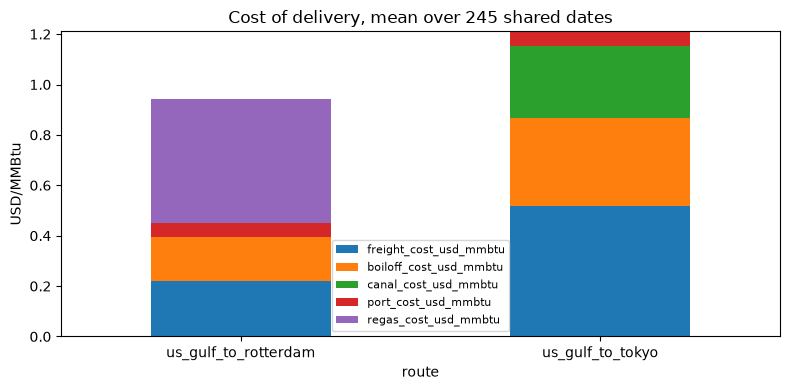

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
stack[costs].plot.bar(stacked=True, ax=ax, rot=0)
ax.set_ylabel("USD/MMBtu")
ax.set_title(f"Cost of delivery, mean over {len(common)} shared dates")
ax.legend(fontsize=8)
fig.tight_layout()

Tokyo pays 0.52 of freight against 0.22 and doubles the boil-off with twice the laden time,
then adds 0.29 of Panama toll; Rotterdam gives back 0.49 of regas instead. Against that,
Tokyo's destination price is only 0.18 higher.

## 3. Netback

The two netbacks and their spread. The spread is blank where only one route has a price: the
routes cover different spans, and comparing them off different dates is how the sign goes
wrong.

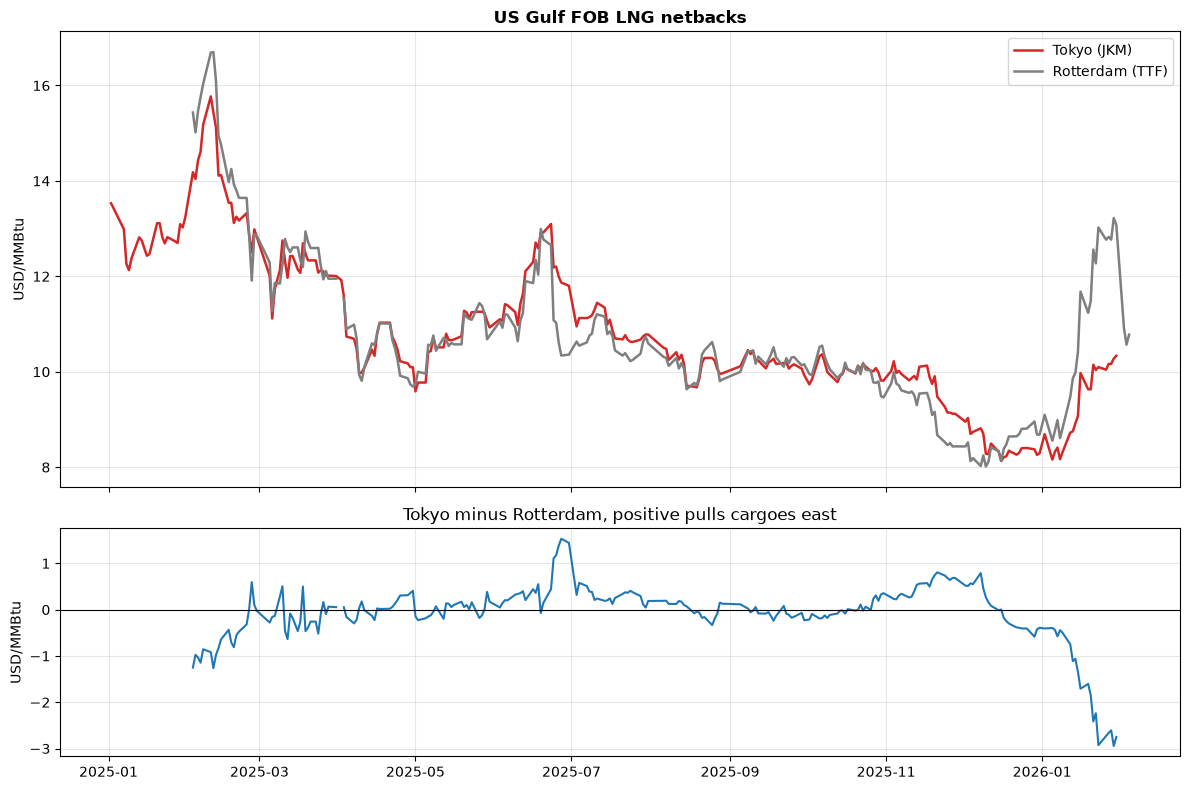

In [5]:
fig, (top, bottom) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, height_ratios=[2, 1])
top.plot(wide.index, wide["us_gulf_to_tokyo"], color="tab:red", lw=1.8, label="Tokyo (JKM)")
top.plot(wide.index, wide["us_gulf_to_rotterdam"], color="tab:gray", lw=1.8, label="Rotterdam (TTF)")
top.set_title("US Gulf FOB LNG netbacks", fontweight="bold")
top.set_ylabel("USD/MMBtu")
top.legend()

bottom.plot(arb["trade_date"], arb["arb_usd_mmbtu"], color="tab:blue", lw=1.5)
bottom.axhline(0.0, color="black", lw=0.8)
bottom.set_title("Tokyo minus Rotterdam, positive pulls cargoes east")
bottom.set_ylabel("USD/MMBtu")

for ax in (top, bottom):
    ax.grid(True, alpha=0.3)
fig.tight_layout()

Both netbacks track their destination market and the spread sits inside 0.5 USD/MMBtu on three
dates out of four, on netbacks around 10.7 - the two markets are close to indifferent. The
tails are not: -2.9 on 29 January 2026, when the Rotterdam netback jumped to 13.2, and +1.5 in
late June.

## 4. Arbitrage

Positive pulls the cargo east. Every crossing of zero is a date the routing decision changed,
and the last row each route covers is where it stands now.

In [6]:
sql("""
    WITH sequenced AS (
        SELECT trade_date, arb_usd_mmbtu,
               LAG(arb_usd_mmbtu) OVER (ORDER BY trade_date) AS previous
        FROM v_netback_arb
        WHERE arb_usd_mmbtu IS NOT NULL
    )
    SELECT trade_date,
           ROUND(previous, 3) AS previous_arb,
           ROUND(arb_usd_mmbtu, 3) AS arb_usd_mmbtu,
           CASE WHEN arb_usd_mmbtu > 0 THEN 'Asia' ELSE 'Europe' END AS now_pays_more
    FROM sequenced
    WHERE previous IS NOT NULL AND SIGN(previous) <> SIGN(arb_usd_mmbtu)
    ORDER BY trade_date
""").tail(10)

,trade_date,previous_arb,arb_usd_mmbtu,now_pays_more
28,2025-10-17,-0.086,0.011,Asia
29,2025-10-20,0.011,-0.019,Europe
30,2025-10-22,-0.007,0.111,Asia
31,2025-10-23,0.111,-0.020,Europe
32,2025-10-24,-0.020,0.064,Asia
33,2025-10-26,0.064,-0.006,Europe
34,2025-10-27,-0.006,0.234,Asia
35,2025-12-15,0.084,-0.013,Europe
36,2025-12-16,-0.013,0.004,Asia
37,2025-12-17,0.004,-0.177,Europe


In [7]:
sql("""
    WITH ranked AS (
        SELECT route, trade_date, dest_contract, freight_contract, netback_usd_mmbtu,
               max_staleness_days,
               ROW_NUMBER() OVER (PARTITION BY route ORDER BY trade_date DESC) AS recency
        FROM netback_panel
    )
    SELECT route, trade_date, dest_contract, freight_contract,
           ROUND(netback_usd_mmbtu, 3) AS netback_usd_mmbtu, max_staleness_days
    FROM ranked
    WHERE recency = 1
    ORDER BY route
""")

,route,trade_date,dest_contract,freight_contract,netback_usd_mmbtu,max_staleness_days
0,us_gulf_to_rotterdam,2026-02-04,TTFH2026,BLNG2H2026,10.777,1
1,us_gulf_to_tokyo,2026-01-30,JKMH2026,BLNG3G2026,10.334,0


38 crossings in a year, most of them a few cents wide: the decision is rarely a strong one.
The routes also end on different dates - a February trade date needs a JKM April contract the
committed CSVs do not have.

## 5. Sensitivity

Nine cents of average spread on a 10.7 netback is thinner than the assumptions behind it, so
the question a trader asks is which one has to move, and by how much, to flip the average
decision.

In [8]:
shared = arb.dropna(subset=["arb_usd_mmbtu"])
gap = shared["arb_usd_mmbtu"].mean()  # negative: Rotterdam nets more on average
tokyo_days = c.ROUTES["us_gulf_to_tokyo"][2] * c.ROUND_TRIP + c.PORT_DAYS
tokyo_rate = panel.loc[panel["route"] == "us_gulf_to_tokyo", "freight_rate_usd_day"].mean()
delivered = (1 - c.BOIL_OFF_PER_DAY) ** c.ROUTES["us_gulf_to_rotterdam"][2]

print(f"mean arb {gap:+.3f} USD/MMBtu, Asia pays more on {(shared['arb_usd_mmbtu'] > 0).mean():.0%} of the shared dates")
print(f"east if BLNG3 falls {-gap * c.CARGO_MMBTU / tokyo_days:,.0f} USD/day, "
      f"{-gap * c.CARGO_MMBTU / tokyo_days / tokyo_rate:.0%} of its {tokyo_rate:,.0f} average")
print(f"east if the Panama toll falls {-gap * c.CARGO_MMBTU:,.0f} of {c.ROUTES['us_gulf_to_tokyo'][3]:,.0f} USD")
print(f"east if Rotterdam regas rises from {c.ROUTES['us_gulf_to_rotterdam'][4]:.2f} "
      f"to {c.ROUTES['us_gulf_to_rotterdam'][4] - gap / delivered:.2f} USD/MMBtu")

mean arb -0.088 USD/MMBtu, Asia pays more on 52% of the shared dates
east if BLNG3 falls 7,327 USD/day, 17% of its 43,493 average
east if the Panama toll falls 307,715 of 1,000,000 USD
east if Rotterdam regas rises from 0.50 to 0.59 USD/MMBtu


The average is a coin flip - Asia pays more on 52% of the dates and loses by 9 cents on the
mean - and a 17% move in one freight curve, a third of the toll or 9 cents of regas is enough
to turn it. The routing call belongs to the daily spread above, not to the average.

## 6. Where this stands

| mean over the 245 shared dates | Tokyo | Rotterdam |
|---|---|---|
| destination price | 11.88 | 11.70 |
| cost of delivery | 1.21 | 0.94 |
| netback | 10.67 | **10.76** |

Three things this does not carry. The cargo is priced to one destination on the trade date, so
the diversion option a real charter holds is worth something this framework does not measure.
Freight is a Baltic round-trip index rather than a ship on subs, and the canal and regas lines
are posted tariffs rather than what a counterparty would negotiate. And the JKM strip in the
committed CSVs ends a few days before the TTF one, so the two routes stop on different dates.